$$
\newcommand{\ket}[1]{|#1\rangle}
\newcommand{\bra}[1]{\langle#1|}
\newcommand{\norm}[1]{\left\lVert#1\right\rVert}
$$


# Hamming Weight

In this notebook, we'll go over some of the `Qubrick`s implemented in `workbench_algorithms` that can be used to compute the Hamming weight of a qubit register.


## Definition 

The "Hamming weight" of a bitstring is defined as the number of 1s in that bitstring. For example, the bitstring `01101` has a Hamming weight of 3. There are some quantum algorithms (e.g. "Hamming Weight Phasing") where we need to compute the Hamming weight of a quantum register and we need to be able to do this coherently so that we can pass in states in superposition and compute the associated hamming weights in superposition.

Therefore, we want a quantum circuit that implements the following operation:

$$
    U_{\text{HamWt}}: \ket{\psi}\ket{0} \rightarrow \ket{\psi}\ket{\text{HamWt}(\psi)} 
$$

## Implementations

Currently, there are three different `Qubrick`s implemented in `workbench_algorithms` to compute the Hamming weight of a qubit register.

While we won't go into detail on how each of these implementations work, we will show you how to use them and do some quick resource estimates to show the relative tradeoffs between them. I'll also note that we'll stick to the default `adder` `Qubrick` (which for these implementations is `GidneyAdd`, but you should be able to supply whichever `adder` you'd like and check if that makes a big difference!).

## ComputeHammingWeightNaive

First and foremost, let's see how to use the `ComputeHammingWeightNaive` `Qubrick`. The algorithm for this circuit is pretty straight forward: allocate an empty register and then serially add the value of the qubits in the `target` register into the `hamming_weight` register. Therefore, for each qubit in the `target` register, you should see a block in the circuit that computes the `add` between these two regsiters and stores the value in the `target` register.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from workbench_algorithms import ComputeHammingWeightNaive
from psiqworkbench import QPU, Qubits
from psiqworkbench.qubricks import  GidneyAdd

/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/interoperability/_tag_class.py:487: Warning: Method 'AdderWithCarry._compute' has parameter 'carry_in' at index 4, but is subtract_condition in AddBase._compute. This is currently a warning to accomodate existing interfaces. It will be upgraded to an error in version 5.0.0 of workbench.
  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/interoperability/_tag_class.py:487: Warning: Method 'AdderWithCarry._compute' has parameter 'carry_in' at index 4, but is subtract_condition in GidneyAdd._compute. This is currently a warning to accomodate existing interfaces. It will be upgraded to an error in version 5.0.0 of workbench.
  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/interoperability/_tag_class.py:487: Warning: Method 'AdderWithCarry._compute' has parameter

Hamming Weight of Bitstring 10111 is 4


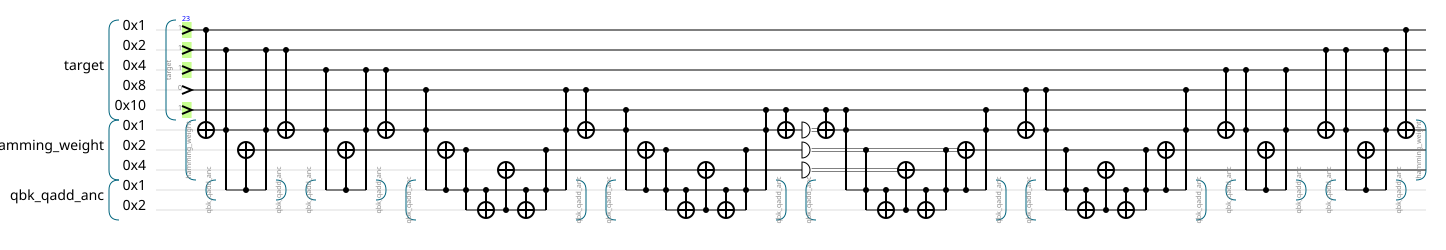

In [3]:
size_of_target = 5
size_of_hamming_weight = int(np.ceil(np.log2(size_of_target+1)))

bitstring = "10111"
qc = QPU()
qc.reset(10)

target = Qubits(size_of_target, "target", qc)
target.write(int(bitstring, 2))

hw = ComputeHammingWeightNaive(adder=GidneyAdd())
hw.compute(target)

hamming_weight = hw.get_result_qreg()


print("Hamming Weight of Bitstring {} is {}".format(bitstring, hamming_weight.read()))

hw.uncompute()

qc.draw()

Try playing around with different bitstrings and convince yourself that it works!

### Registers in Superposition

As mentioned above, we need to compute this function coherently, so let's try passing in a bell state!

Hamming Weight of Bell-State on 5 Qubits is...
|target|hamming_weight|?>
|0|0|.>    0.707107+0.000000j
|31|5|.>    0.707107+0.000000j


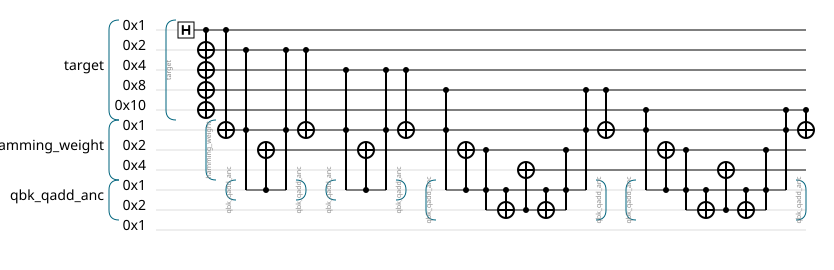

In [4]:
size_of_target = 5
size_of_hamming_weight = int(np.ceil(np.log2(size_of_target+1)))

qc = QPU()
qc.reset(11)

target = Qubits(size_of_target, "target", qc)
target[0].had()
target[1:].x(target[0])

hw = ComputeHammingWeightNaive()
hw.compute(target)

hamming_weight = hw.get_result_qreg()

print("Hamming Weight of Bell-State on {} Qubits is...".format(size_of_target))
qc.print_state_vector()
qc.draw()

In [5]:
# Let's check the bit-string for 31
print(bin(31)) # HamWt(bin(31)) should be 5

0b11111


Indeed, in the printed state vector, we see the correct Hamming weights of the states with indices 0 and 31.

## ComputeHammingWeightGroupOfThrees

The `ComputeHammingWeightGroupOfThrees` `Qubrick` is a much more gate-efficient method to compute the Hamming weight! The catch is that it uses a linear number of ancillae and is much more costly when controlled.

Roughly, in this qubrick, the Hamming weight is computed by taking size-3 subsets of the target register and adding them up, followed by taking the results and adding up with remaining subsets until there are no remaining qubits in the target register.

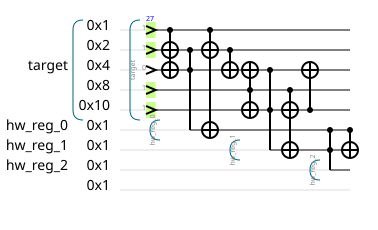

Hamming Weight of Bitstring 11011 is 4


In [6]:
from workbench_algorithms import ComputeHammingWeightGroupOfThrees

size_of_target = 5
size_of_hamming_weight = int(np.ceil(np.log2(size_of_target+1)))

bitstring = "11011"
qc = QPU()
qc.reset(9)

target = Qubits(size_of_target, "target", qc)
target.write(int(bitstring, 2))

hw = ComputeHammingWeightGroupOfThrees()
hw.compute(target)

hamming_weight = hw.get_result_qreg()

qc.draw()

print("Hamming Weight of Bitstring {} is {}".format(bitstring, hamming_weight.read()))

## ComputeHammingWeightBinaryRecursion

A nice implementation that uses fewer (but still linear) ancillae and around the same number of Toffoli is the `ComputeHammingWeightBinaryRecursion` `Qubrick`.

This method is somewhat similar to the one above in spirit (in terms of using subsets of target register qubits), but uses parallel implementations of half-adders, then adds up the results using larger adders going through a binary tree structure.

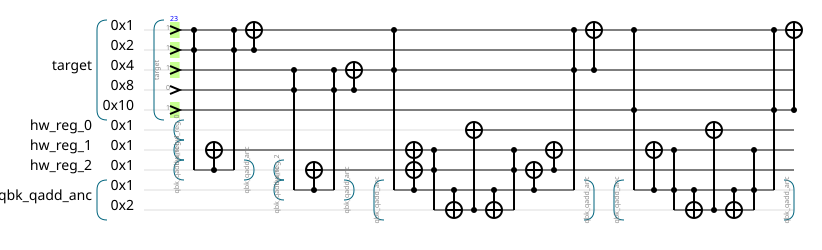

Hamming Weight of Bitstring 10111 is 4


In [7]:
from workbench_algorithms import ComputeHammingWeightBinaryRecursion

size_of_target = 5
size_of_hamming_weight = int(np.ceil(np.log2(size_of_target+1)))

bitstring = "10111"
qc = QPU()
qc.reset(10)

target = Qubits(size_of_target, "target", qc)
target.write(int(bitstring, 2))

hw = ComputeHammingWeightBinaryRecursion()
hw.compute(target)

hamming_weight = hw.get_result_qreg()

qc.draw()

print("Hamming Weight of Bitstring {} is {}".format(bitstring, hamming_weight.read()))

## Resource Estimation

Let's make some pretty plots that show some of the resource estimates of these different implementations!

For a range of system sizes, we will plot the number of Toffoli each method uses, and then we also plot the number of ancillae each method uses. We will plot this for the three Qubricks demonstrated above, for both the uncontrolled and controlled versions of these routines.

In [8]:
import matplotlib.pyplot as plt
import numpy as np

color1 = "#D81B60"
color2 = "#1F85DE"
color3 = "#DE781F"
color4 = "#004D40"
color5 = "#e31ceb"
color6 = "black"

In [9]:
def get_metrics(qubrick_cls, size_of_system, controlled=False):
    qc = QPU(filters=[">>buffer>>"])
    qc.reset(2000)
    
    ctrl = 0
    qubs = Qubits(size_of_system, "qubs", qc)
    if controlled:
        ctrl = Qubits(1, "ctrl", qc)
    
    hw_computer = qubrick_cls()
    
    hw_computer.compute(qubs, ctrl=ctrl)
    hw_computer.uncompute()
    
    return qc.metrics()

In [ ]:
system_sizes = range(5, 50, 5)

uncontrolled_binr_ancillae = []
uncontrolled_naive_ancillae = []
uncontrolled_go3_ancillae = []

controlled_binr_ancillae = []
controlled_naive_ancillae = []
controlled_go3_ancillae = []

uncontrolled_binr_toffoli = []
uncontrolled_naive_toffoli = []
uncontrolled_go3_toffoli = []

controlled_binr_toffoli = []
controlled_naive_toffoli = []
controlled_go3_toffoli = []

for size in system_sizes:
    non_ancillae_qubit_counts = int(np.ceil(size + np.log2(size+1)))
    
    metrics = get_metrics(ComputeHammingWeightBinaryRecursion, size, controlled=False)
    uncontrolled_binr_ancillae.append(metrics["qubit_highwater"] - non_ancillae_qubit_counts - 1)
    uncontrolled_binr_toffoli.append(metrics["toffoli_count"])
    
    metrics = get_metrics(ComputeHammingWeightBinaryRecursion, size, controlled=True)
    controlled_binr_ancillae.append(metrics["qubit_highwater"] - non_ancillae_qubit_counts)
    controlled_binr_toffoli.append(metrics["toffoli_count"])
    
    metrics = get_metrics(ComputeHammingWeightNaive, size, controlled=False)
    uncontrolled_naive_ancillae.append(metrics["qubit_highwater"] - non_ancillae_qubit_counts)
    uncontrolled_naive_toffoli.append(metrics["toffoli_count"])
    
    metrics = get_metrics(ComputeHammingWeightNaive, size, controlled=True)
    controlled_naive_ancillae.append(metrics["qubit_highwater"] - non_ancillae_qubit_counts - 1)
    controlled_naive_toffoli.append(metrics["toffoli_count"])
    
    metrics = get_metrics(ComputeHammingWeightGroupOfThrees, size, controlled=False)
    uncontrolled_go3_ancillae.append(metrics["qubit_highwater"] - non_ancillae_qubit_counts)
    uncontrolled_go3_toffoli.append(metrics["toffoli_count"])
    
    metrics = get_metrics(ComputeHammingWeightGroupOfThrees, size, controlled=True)
    controlled_go3_ancillae.append(metrics["qubit_highwater_upper_bound"] - non_ancillae_qubit_counts - 1)
    controlled_go3_toffoli.append(metrics["toffoli_count"])
    

/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost

{'qubit_highwater_lower_bound': 11, 'qubit_highwater_upper_bound': 12, 'pprs': 0, 'ppms': 0, 'active_volume': 1269, 'toffoli_count': 25, 'measurement_count': 19, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 24}
{'qubit_highwater_lower_bound': 21, 'qubit_highwater_upper_bound': 22, 'pprs': 0, 'ppms': 0, 'active_volume': 3370, 'toffoli_count': 66, 'measurement_count': 50, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 60}
{'qubit_highwater_lower_bound': 31, 'qubit_highwater_upper_bound': 32, 'pprs': 0, 'ppms': 0, 'active_volume': 5311, 'toffoli_count': 103, 'measurement_count': 81, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 96}
{'qubit_highwater_lower_bound': 41, 'qubit_highwater_upper_bound': 42, 'pprs': 0, 'ppms': 0, 'active_volume': 7796, 'toffoli_count': 152, 'measurement_count': 116, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 136}


/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost

{'qubit_highwater_lower_bound': 51, 'qubit_highwater_upper_bound': 52, 'pprs': 0, 'ppms': 0, 'active_volume': 9929, 'toffoli_count': 193, 'measurement_count': 149, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 174}
{'qubit_highwater_lower_bound': 61, 'qubit_highwater_upper_bound': 62, 'pprs': 0, 'ppms': 0, 'active_volume': 12062, 'toffoli_count': 234, 'measurement_count': 182, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 212}
{'qubit_highwater_lower_bound': 71, 'qubit_highwater_upper_bound': 72, 'pprs': 0, 'ppms': 0, 'active_volume': 14355, 'toffoli_count': 279, 'measurement_count': 215, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 250}


/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost

{'qubit_highwater_lower_bound': 81, 'qubit_highwater_upper_bound': 82, 'pprs': 0, 'ppms': 0, 'active_volume': 16872, 'toffoli_count': 328, 'measurement_count': 252, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 292}
{'qubit_highwater_lower_bound': 91, 'qubit_highwater_upper_bound': 92, 'pprs': 0, 'ppms': 0, 'active_volume': 18813, 'toffoli_count': 365, 'measurement_count': 283, 'rotation_count': 0, 't_count': 0, 'total_num_ops': 328}


/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost), but you may be missing some costs.

  warn(
/Users/vrusso/Projects/psi_quantum/workbench_algorithms/.venv/lib/python3.12/site-packages/psiqworkbench/resource_estimation/witness_counter/witness_metrics_functions.py:104: UserWarning: Some ops were not processed by this metrics function!
This may be expected (some ops like qubrick ops have no cost

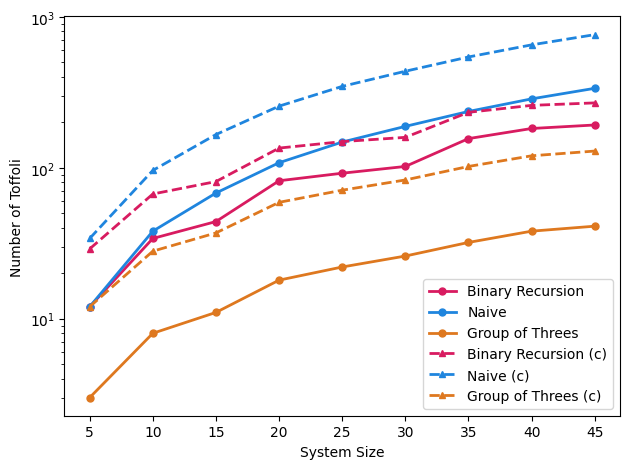

In [ ]:
fig, ax1 = plt.subplots()
ax1.set_ylabel("Number of Toffoli")
ax1.set_xlabel("System Size") 
ax1.plot(system_sizes, uncontrolled_binr_toffoli, color=color1, lw=2, linestyle="-", marker="o", ms=5, label="Binary Recursion")
ax1.plot(system_sizes, uncontrolled_naive_toffoli, color=color2, lw=2, linestyle="-", marker="o", ms=5, label="Naive")
ax1.plot(system_sizes, uncontrolled_go3_toffoli, color=color3, lw=2, linestyle="-", marker="o", ms=5, label="Group of Threes")

# Controlled versions
ax1.plot(system_sizes, controlled_binr_toffoli, color=color1, lw=2, linestyle="--", marker="^", ms=5, label="Binary Recursion (c)")
ax1.plot(system_sizes, controlled_naive_toffoli, color=color2, lw=2, linestyle="--", marker="^", ms=5, label="Naive (c)")
ax1.plot(system_sizes, controlled_go3_toffoli, color=color3, lw=2, linestyle="--", marker="^", ms=5, label="Group of Threes (c)")

plt.yscale('log')

plt.legend()
fig.tight_layout()
plt.show()

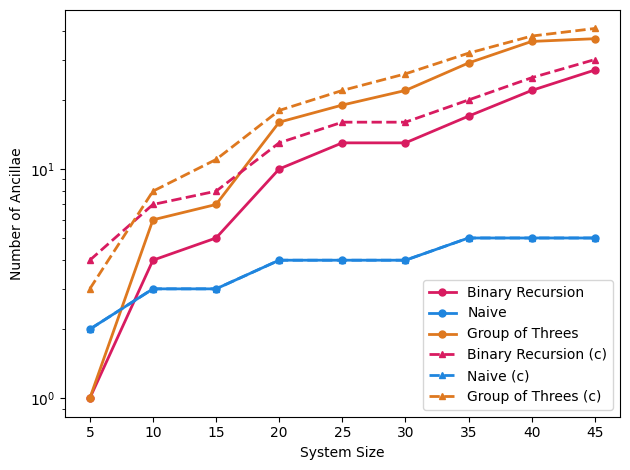

In [ ]:
fig, ax1 = plt.subplots()
ax1.set_ylabel("Number of Ancillae")
ax1.set_xlabel("System Size") 
ax1.plot(system_sizes, uncontrolled_binr_ancillae, color=color1, lw=2, linestyle="-", marker="o", ms=5, label="Binary Recursion")
ax1.plot(system_sizes, uncontrolled_naive_ancillae, color=color2, lw=2, linestyle="-", marker="o", ms=5, label="Naive")
ax1.plot(system_sizes, uncontrolled_go3_ancillae, color=color3, lw=2, linestyle="-", marker="o", ms=5, label="Group of Threes")

# Controlled versions
ax1.plot(system_sizes, controlled_binr_ancillae, color=color1, lw=2, linestyle="--", marker="^", ms=5, label="Binary Recursion (c)")
ax1.plot(system_sizes, controlled_naive_ancillae, color=color2, lw=2, linestyle="--", marker="^", ms=5, label="Naive (c)")
ax1.plot(system_sizes, controlled_go3_ancillae, color=color3, lw=2, linestyle="--", marker="^", ms=5, label="Group of Threes (c)")

plt.yscale('log')


plt.legend()
fig.tight_layout()
plt.show()